<a href="https://colab.research.google.com/github/MojiburRahaman/colab-project/blob/main/object_tracking/Object_Tracking_%26_Heatmap_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/TAHMID37/Computer-Vision
%cd /content/Computer-Vision
!pip install -r requirements.txt

Cloning into 'Computer-Vision'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 20 (delta 1), reused 15 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 6.95 MiB | 13.86 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/Computer-Vision
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 41.1 MB/s eta 0:00:00


In [2]:
import cv2
import numpy as np
from ultralytics import YOLO
import sys
from IPython.display import Video
from IPython.display import HTML
from base64 import b64encode
from IPython.display import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
VIDEO_PATH = 'https://media.roboflow.com/supervision/video-examples/people-walking.mp4'
MODEL_PATH = 'yolo11x.pt'

# Annotation
ANNOT_LINE_IN_START = (0, 153)
ANNOT_LINE_IN_END = (1625, 153)
ANNOT_LINE_OUT_START = (0, 762)
ANNOT_LINE_OUT_END = (1625, 762)
ANNOT_W, ANNOT_H = 1625, 906

# Person class ID in COCO dataset
PERSON_CLASS_ID  = [0]

In [9]:
def process_video(video_path=VIDEO_PATH, output_path="output.mp4", conf_threshold=0.25): # Added conf_threshold parameter
    try:
        model = YOLO(MODEL_PATH)
    except Exception as e:
        print(f"\n[ERROR] Failed to load YOLO model from '{MODEL_PATH}'.")
        print("Error details:", e)
        sys.exit(1)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Failed to open video file.")
        return

    # Read first frame to get size
    ret, frame = cap.read()
    if not ret:
        print("Failed to read first frame.")
        return
    orig_h, orig_w = frame.shape[:2]

    # Scale annotation coordinates
    def scale_point(pt):
        x, y = pt
        return (int(x * orig_w / ANNOT_W), int(y * orig_h / ANNOT_H))

    LINE_IN_START = scale_point(ANNOT_LINE_IN_START)
    LINE_IN_END = scale_point(ANNOT_LINE_IN_END)
    LINE_OUT_START = scale_point(ANNOT_LINE_OUT_START)
    LINE_OUT_END = scale_point(ANNOT_LINE_OUT_END)

    # Prepare output writer
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, 20, (960, 540))

    # Add a check to see if the VideoWriter was initialized successfully
    if not out.isOpened():
        print(f"Error: Could not open video writer for path {output_path}")
        return

    print(f"Video writer initialized for {output_path}") # Debug print

    # Reset video to start
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    in_count, out_count = 0, 0
    already_counted_in, already_counted_out = set(), set()
    track_history = {}
    object_colors = {} # Dictionary to store color for each track ID
    all_centers = [] # List to store all collected center points for heatmap

    frame_count = 0 # Debug counter

    while True:
        ret, frame = cap.read()
        if not ret:
            print(f"End of video or failed to read frame at count {frame_count}") # Debug print
            break

        frame_count += 1 # Increment debug counter

        results = model.track(frame, persist=True, tracker="botsort.yaml", verbose=False, conf=conf_threshold)[0] # Added conf=conf_threshold
        boxes = results.boxes
        if boxes is None or boxes.xyxy is None:
            display_frame = cv2.resize(frame, (960, 540))
            out.write(display_frame)
            print(f"Wrote frame {frame_count} (no detections)") # Debug print
            continue

        class_ids = boxes.cls.cpu().numpy().astype(int)
        xyxy = boxes.xyxy.cpu().numpy()
        track_ids = boxes.id.cpu().numpy().astype(int) if boxes.id is not None else [None]*len(xyxy)
        person_indices = [i for i, cid in enumerate(class_ids) if cid in PERSON_CLASS_ID] # Corrected comparison

        # Draw lines
        cv2.line(frame, LINE_IN_START, LINE_IN_END, (255, 0, 0), 2)
        cv2.line(frame, LINE_OUT_START, LINE_OUT_END, (0, 0, 255), 2)

        for idx in person_indices:
            x1, y1, x2, y2 = map(int, xyxy[idx])
            track_id = track_ids[idx]
            center = ((x1 + x2) // 2, (y1 + y2) // 2)
            all_centers.append(center) # Collect center point for heatmap

            if track_id not in track_history:
                track_history[track_id] = []
                object_colors[track_id] = (0, 255, 255) # Default color cyan
            track_history[track_id].append(center)
            if len(track_history[track_id]) > 2:
                track_history[track_id] = track_history[track_id][-2:]

            if len(track_history[track_id]) == 2:
                prev_center, curr_center = track_history[track_id]

                # Line IN: trajectory moves down and crosses the upper line
                if (LINE_IN_START[0] <= prev_center[0] <= LINE_IN_END[0] and
                    LINE_IN_START[0] <= curr_center[0] <= LINE_IN_END[0]):
                    if prev_center[1] < LINE_IN_START[1] and curr_center[1] >= LINE_IN_START[1] and track_id not in already_counted_in:
                        in_count += 1
                        already_counted_in.add(track_id)
                        object_colors[track_id] = (0, 255, 0) # Change color to green for 'in'

                # Line OUT: trajectory moves up and crosses the lower line
                if (LINE_OUT_START[0] <= prev_center[0] <= LINE_OUT_END[0] and
                    LINE_OUT_START[0] <= curr_center[0] <= LINE_OUT_END[0]):
                    if prev_center[1] > LINE_OUT_START[1] and curr_center[1] <= LINE_OUT_START[1] and track_id not in already_counted_out:
                        out_count += 1
                        already_counted_out.add(track_id)
                        object_colors[track_id] = (0, 0, 255) # Change color to red for 'out'

            # Draw bbox + ID with updated color
            current_color = object_colors.get(track_id, (0, 255, 255)) # Get color, default to cyan if not found
            cv2.rectangle(frame, (x1, y1), (x2, y2), current_color, 2)
            cv2.circle(frame, center, 5, current_color, -1)
            cv2.putText(frame, f'ID {track_id}', (center[0] - 10, center[1] - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, current_color, 2)


        # Counts
        cv2.putText(frame, f'In: {in_count}', (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 2.2, (0,255,0), 5)
        cv2.putText(frame, f'Out: {out_count}', (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 2.2, (0,0,255), 5)

        display_frame = cv2.resize(frame, (960, 540))
        out.write(display_frame)

    cap.release()
    out.release()
    print(f"✅ Processing complete. Saved to {output_path}")
    return all_centers # Return the collected center points for heatmap

In [10]:

process_video(VIDEO_PATH, "output.mp4")

Video writer initialized for output.mp4
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

End of video or failed to read frame at count 341
✅ Processing complete. Saved to output.mp4


[(1465, 795),
 (704, 750),
 (1192, 1013),
 (86, 891),
 (787, 536),
 (1502, 557),
 (1172, 581),
 (1480, 402),
 (737, 314),
 (956, 239),
 (295, 524),
 (1014, 168),
 (1112, 95),
 (1229, 197),
 (1188, 214),
 (823, 142),
 (597, 339),
 (373, 571),
 (1821, 209),
 (119, 191),
 (1720, 214),
 (1461, 795),
 (707, 742),
 (1193, 1009),
 (89, 894),
 (788, 532),
 (1505, 562),
 (1173, 576),
 (1484, 403),
 (736, 305),
 (956, 245),
 (292, 526),
 (1016, 167),
 (1112, 98),
 (1228, 192),
 (1189, 214),
 (825, 139),
 (599, 344),
 (373, 570),
 (1823, 213),
 (119, 190),
 (1721, 222),
 (1459, 795),
 (708, 735),
 (1192, 1006),
 (91, 895),
 (789, 527),
 (1506, 564),
 (1174, 571),
 (1485, 403),
 (738, 302),
 (956, 248),
 (291, 526),
 (1016, 169),
 (1112, 100),
 (1228, 189),
 (1189, 213),
 (826, 138),
 (599, 346),
 (373, 570),
 (1823, 215),
 (119, 190),
 (1886, 783),
 (420, 591),
 (1457, 795),
 (709, 726),
 (1192, 1004),
 (91, 896),
 (790, 521),
 (1507, 565),
 (1174, 566),
 (1486, 404),
 (738, 299),
 (955, 248),
 (

In [11]:

import base64
import subprocess
from IPython.display import HTML, display

output_path = "output.mp4"        # Original video
final_output = "output_h264.mp4"  # Converted video

# Run ffmpeg to convert to H.264
ffmpeg_cmd = [
    "ffmpeg", "-y", "-i", output_path,
    "-c:v", "libx264", "-pix_fmt", "yuv420p", "-movflags", "+faststart",
    "-c:a", "aac", "-ar", "44100", "-ac", "2", "-b:a", "128k",
    final_output
]
subprocess.run(ffmpeg_cmd, check=True)

# Encode the converted video to base64
with open(final_output, "rb") as f:
    mp4 = f.read()

data_url = "data:video/mp4;base64," + base64.b64encode(mp4).decode()

# Display video in Jupyter
display(HTML(f"""
<video width="640" height="480" controls autoplay loop muted>
  <source src="{data_url}" type="video/mp4">
</video>
"""))



**Heatmap**:




In [12]:
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    print("Failed to open video file.")
    # Need to handle this case, maybe finish the task with failure
else:
    ret, frame = cap.read()
    if not ret:
        print("Failed to read first frame.")
        # Need to handle this case, maybe finish the task with failure
    else:
        orig_h, orig_w = frame.shape[:2]
        cap.release()

        # Initialize density map
        density_map = np.zeros((orig_h, orig_w), dtype=np.float32)

In [14]:
PERSON_CLASS_ID = [0]  # COCO person

def process_video(video_path=VIDEO_PATH, output_path="output.mp4", conf_threshold=0.25):
    model = YOLO(MODEL_PATH)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Failed to open video file.")
        return []

    ret, frame = cap.read()
    if not ret:
        print("Failed to read first frame.")
        return []
    orig_h, orig_w = frame.shape[:2]

    def scale_point(pt):
        x, y = pt
        return (int(x * orig_w / ANNOT_W), int(y * orig_h / ANNOT_H))

    LINE_IN_START = scale_point(ANNOT_LINE_IN_START)
    LINE_IN_END = scale_point(ANNOT_LINE_IN_END)
    LINE_OUT_START = scale_point(ANNOT_LINE_OUT_START)
    LINE_OUT_END = scale_point(ANNOT_LINE_OUT_END)

    fourcc = cv2.VideoWriter_fourcc(*"avc1")
    out = cv2.VideoWriter(output_path, fourcc, 20, (960, 540))
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    in_count, out_count = 0, 0
    already_counted_in, already_counted_out = set(), set()
    track_history = {}
    object_colors = {}

    all_centers = []  # <-- collect all centers here

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model.predict(frame, conf=conf_threshold)[0]  # DETECTION ONLY
        boxes = results.boxes

        if boxes is not None and boxes.xyxy is not None:
            class_ids = boxes.cls.cpu().numpy().astype(int)
            xyxy = boxes.xyxy.cpu().numpy()

            # Filter only persons
            person_indices = [i for i, cid in enumerate(class_ids) if cid in PERSON_CLASS_ID]

            for idx in person_indices:
                x1, y1, x2, y2 = map(int, xyxy[idx])

                # Use **foot point** instead of center
                center = ((x1 + x2) // 2, y2)  # bottom center (foot)

                all_centers.append(center)

                # Use center as temporary track_id (just for visualization)
                track_id = idx
                if track_id not in object_colors:
                    object_colors[track_id] = (0, 255, 255)

                cv2.rectangle(frame, (x1, y1), (x2, y2), object_colors[track_id], 2)
                cv2.circle(frame, center, 5, object_colors[track_id], -1)
                cv2.putText(frame, f'ID {track_id}', (center[0]-10, center[1]-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, object_colors[track_id], 2)

        # Draw lines
        cv2.line(frame, LINE_IN_START, LINE_IN_END, (255, 0, 0), 2)
        cv2.line(frame, LINE_OUT_START, LINE_OUT_END, (0, 0, 255), 2)

        cv2.putText(frame, f'In: {in_count}', (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 2.2, (0,255,0), 5)
        cv2.putText(frame, f'Out: {out_count}', (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 2.2, (0,0,255), 5)

        display_frame = cv2.resize(frame, (960, 540))
        out.write(display_frame)

    cap.release()
    out.release()
    print(f"✅ Processing complete. Saved to {output_path}")

    return all_centers  # <-- return the collected centers

In [15]:
# Assuming 'all_centers' is available from the previous step
all_centers = process_video(VIDEO_PATH, "output.mp4")

# Iterate through the collected center points and increment the density map at the corresponding coordinates, applying a small radius for smoothing.
for center in all_centers:
    x, y = center
    # Simple smoothing by incrementing a small area around the center
    # Define a radius for smoothing
    radius = 10
    y_min = max(0, y - radius)
    y_max = min(orig_h, y + radius + 1)
    x_min = max(0, x - radius)
    x_max = min(orig_w, x + radius + 1)
    density_map[y_min:y_max, x_min:x_max] += 1


0: 384x640 21 persons, 1 handbag, 46.7ms
Speed: 2.0ms preprocess, 46.7ms inference, 9.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 23 persons, 2 handbags, 1 tennis racket, 45.8ms
Speed: 2.9ms preprocess, 45.8ms inference, 11.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 22 persons, 2 backpacks, 4 handbags, 1 tennis racket, 39.7ms
Speed: 4.9ms preprocess, 39.7ms inference, 12.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 24 persons, 3 backpacks, 2 handbags, 39.0ms
Speed: 3.5ms preprocess, 39.0ms inference, 12.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 23 persons, 3 handbags, 38.0ms
Speed: 2.8ms preprocess, 38.0ms inference, 11.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 22 persons, 3 handbags, 33.2ms
Speed: 2.8ms preprocess, 33.2ms inference, 10.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 25 persons, 2 backpacks, 3 handbags, 29.5ms
Speed: 3.0ms preprocess, 29.5ms inferenc

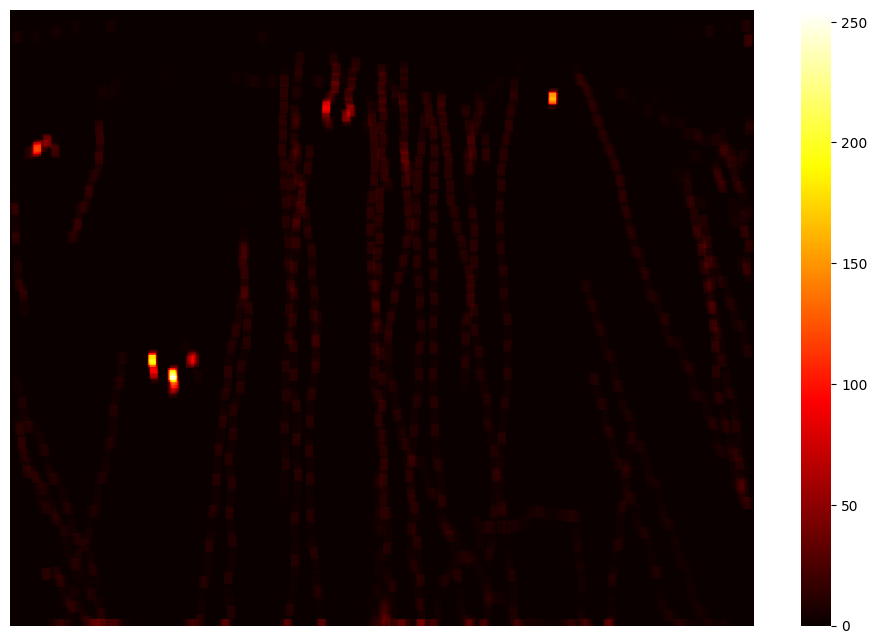

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(density_map, cmap='hot')
plt.axis('off')
plt.xticks([])
plt.yticks([])
plt.show()

Heatmap overlay saved as heatmap_overlay.png


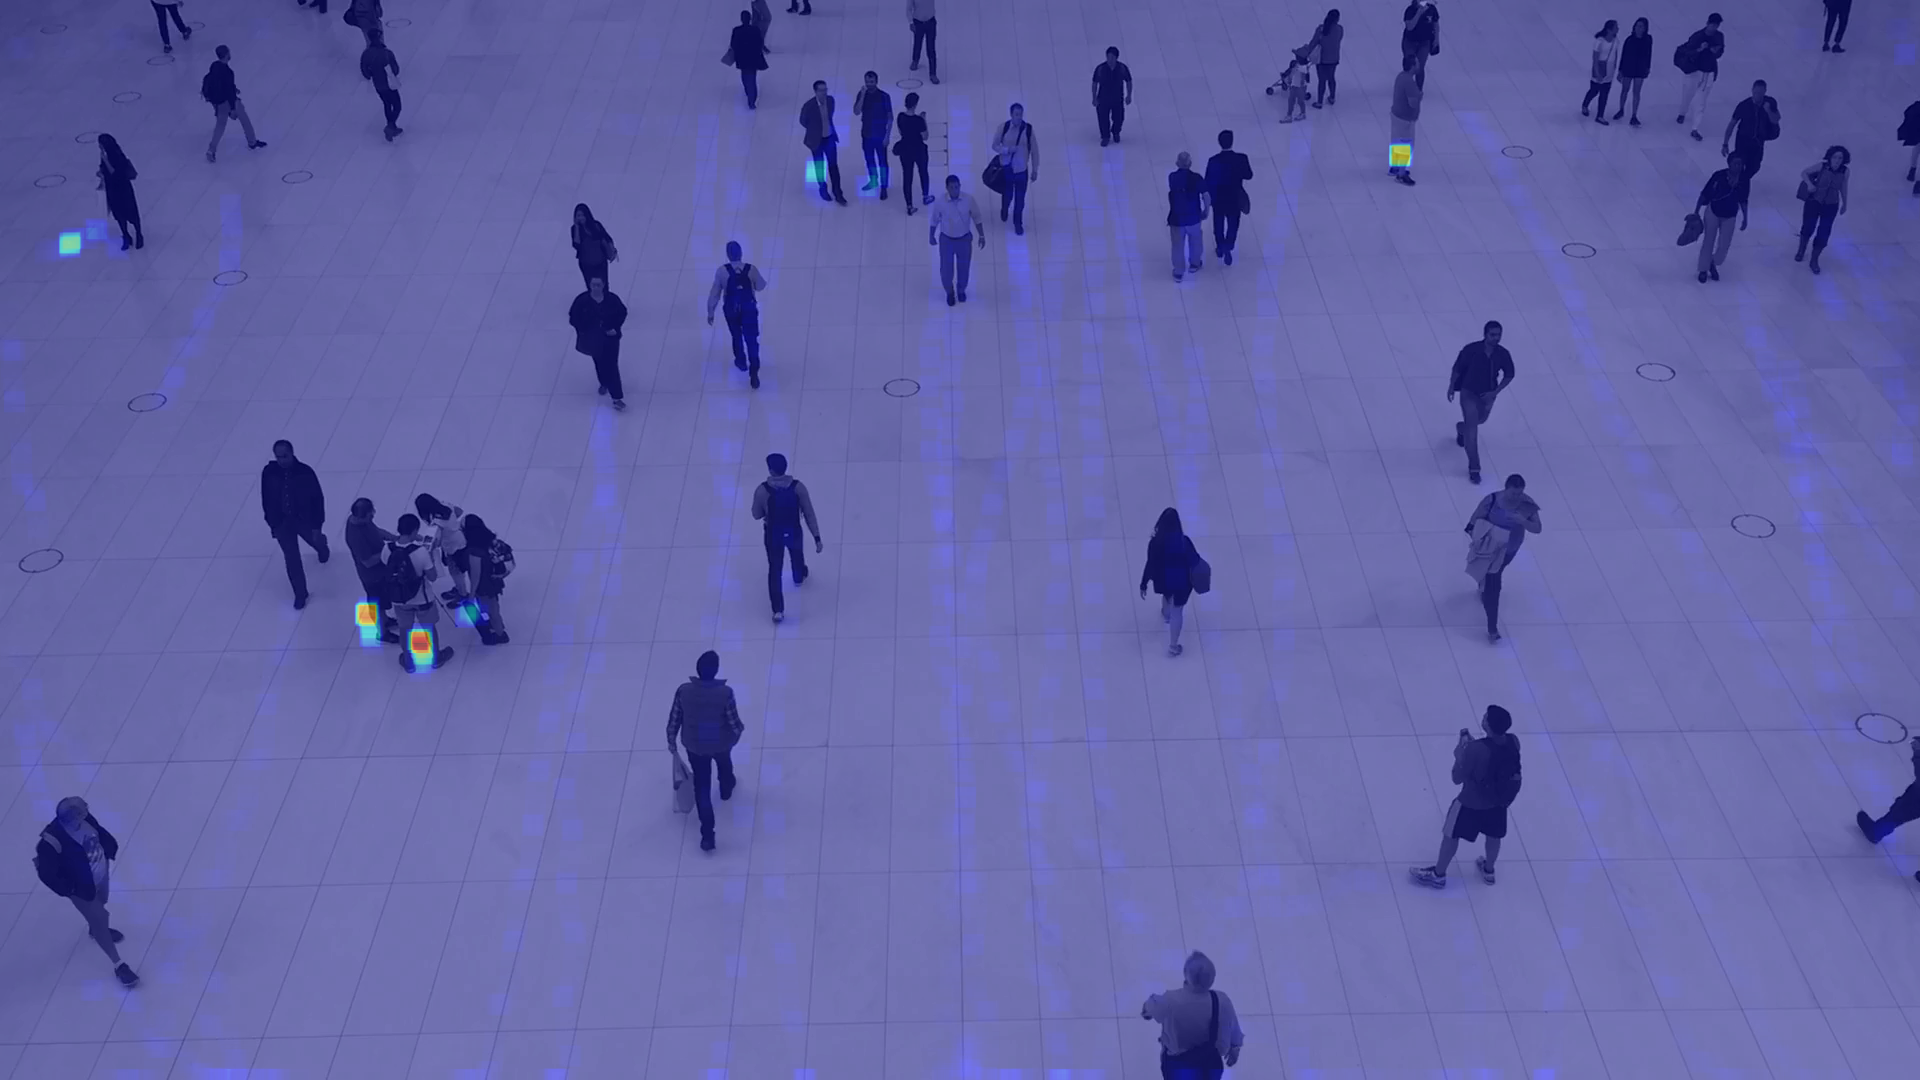

In [17]:
# Convert density map to 8-bit grayscale
density_map_normalized = cv2.normalize(density_map, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
density_map_colored = cv2.applyColorMap(density_map_normalized, cv2.COLORMAP_JET)

# Read the first frame of the video
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()

if ret:
    # Resize the colored heatmap to match the frame dimensions
    heatmap_resized = cv2.resize(density_map_colored, (frame.shape[1], frame.shape[0]))

    # Blend the frame and the heatmap
    alpha = 0.5  # Transparency factor
    overlay = cv2.addWeighted(frame, 1 - alpha, heatmap_resized, alpha, 0)

    # Display the overlaid image
    cv2.imwrite("heatmap_overlay.png", overlay)
    print("Heatmap overlay saved as heatmap_overlay.png")

    # Display the saved image in the notebook
    display(Image("heatmap_overlay.png"))

else:
    print("Failed to read the first frame for overlay.")

# People Counting and Heatmap Generation

This notebook demonstrates a computer vision pipeline for counting people crossing defined lines in a video and generating a heatmap of their movement.

## Detection Method

The system uses the **YOLOv8** object detection model to identify persons in each frame of the video. Specifically, it utilizes a pre-trained `yolov8n.pt` model (though the code currently references `yolo11x.pt`, the principle is the same for YOLO models). The model processes each frame and provides bounding box coordinates and class IDs for detected objects. Only objects classified as 'person' (class ID 0 in the COCO dataset) are considered for tracking and counting.

## Line Coordinates

Two lines are defined to count people moving "in" and "out". These lines are defined by their start and end coordinates in the video frame. The coordinates are initially defined based on an assumed video resolution (`ANNOT_W`, `ANNOT_H`) and then scaled to match the actual resolution of the input video.

*   **Line IN (Blue):** Defined by `ANNOT_LINE_IN_START` and `ANNOT_LINE_IN_END`. This line is typically placed towards the top of the area of interest.
*   **Line OUT (Red):** Defined by `ANNOT_LINE_OUT_START` and `ANNOT_LINE_OUT_END`. This line is typically placed towards the bottom of the area of interest.

The scaled coordinates (`LINE_IN_START`, `LINE_IN_END`, `LINE_OUT_START`, `LINE_OUT_END`) are used for drawing the lines on the video frames and for the counting logic.

## Logic Explanation for IN/OUT Counting

The counting logic relies on tracking the movement of the detected persons.

1.  **Object Tracking:** The `model.track()` function (or `model.predict()` followed by a tracking algorithm like `botsort.yaml` as seen in the code) is used to assign a unique track ID to each detected person and maintain a history of their positions (specifically, the bottom-center or 'foot' point of the bounding box is used as the representative point for tracking).
2.  **Trajectory Analysis:** For each tracked person, the system keeps track of their recent positions (typically the last two).
3.  **Counting:**
    *   An "IN" count is incremented when a person's trajectory crosses the **Line IN** in a downward direction (i.e., the previous position was above the line and the current position is on or below the line). To avoid double-counting, the system keeps track of individuals who have already been counted as "in".
    *   An "OUT" count is incremented when a person's trajectory crosses the **Line OUT** in an upward direction (i.e., the previous position was below the line and the current position is on or above the line). Similarly, individuals are marked to prevent double-counting as "out".

The counts are displayed on the output video frame.

## Heatmap Generation

A heatmap is generated to visualize the areas of highest person density throughout the video.

1.  **Collecting Center Points:** As each person is detected and tracked, their representative point (the foot point) is collected.
2.  **Creating a Density Map:** A 2D array (density map) with the same dimensions as the video frame is initialized with zeros. For each collected person point, the corresponding location in the density map is incremented. A small radius around the point is also incremented to create a smoother heatmap effect.
3.  **Visualization:** The density map is normalized and colored (using a colormap like 'hot' or 'jet') to create a visual representation of the density. This colored heatmap is then overlaid on the first frame of the video to show the areas of high traffic in the context of the scene.

This process provides both quantitative data (IN/OUT counts) and a qualitative visualization (heatmap) of people's movement within the video frame.